# Modelo: VisualCF

- Embeddings: CLIP ViT-B/32 (512 dimensiones)

In [8]:
import sys
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
sys.path.append("..")
from src.evaluation import temporal_train_test_split, evaluate_model
from src.image_features import CLIPFeatureExtractor

MODEL_NAME = "visualcf"
RESULTS_DIR = f"../results/{MODEL_NAME}"
N_FACTORS = 50


## Definición del modelo

In [9]:
class VisualCF:
    """
    Método para combinar la predicción de SVD (filtrado colaborativo) con
    la similitud coseno entre el perfil visual del usuario y los
    embeddings de los items obtenidos con CLIP.

    score(u,i) = alpha * norm(SVD_score(u,i)) + (1-alpha) * cosine(user_visual_profile, clip_emb_i)

    El perfil del usuario se calcula a partir del promedio de los embeddings
    de los items obtenidos con CLIP que son valorados con rating >= like_threshold en train.
    """

    def __init__(self, image_embeddings, svd_model, alpha=0.5, like_threshold=4.0):
        self.alpha = alpha
        self.threshold = like_threshold
        self.svd = svd_model

        # Preparación de embeddings
        self.b_ids = list(image_embeddings.keys())
        self.emb_matrix = np.array(list(image_embeddings.values()))
        self.b_idx_map = {b_id: i for i, b_id in enumerate(self.b_ids)}

    def get_user_profile(self, user_id, reviews_df):
        # Filtramos los reviews del usuario
        user_reviews = reviews_df[reviews_df["user_id"] == user_id]
        if user_reviews.empty:
            return None

        liked_df = user_reviews[user_reviews["stars"] >= self.threshold]

        # Si no hay likes por encima del threshold, usamos todos sus reviews como fallback
        if not liked_df.empty:
            target_df = liked_df
        else:
            target_df = user_reviews

        valid_bids = [b for b in target_df["business_id"] if b in self.b_idx_map]
        if not valid_bids:
            return None

        # Promediamos los embeddings de los locales visitados
        indices = [self.b_idx_map[b] for b in valid_bids]
        return np.mean(self.emb_matrix[indices], axis=0)

    def get_normalized_svd(self, user_id):
        if user_id not in self.svd["user_index"]:
            return {}

        u_idx = self.svd["user_index"][user_id]
        raw_scores = self.svd["predicted"][u_idx]

        vmin = raw_scores.min()
        vmax = raw_scores.max()
        denom = vmax - vmin
        # Evitamos división por cero
        if denom == 0.0:
            denom = 1.0

        idx_to_b = {v: k for k, v in self.svd["item_index"].items()}

        return {
            idx_to_b[j]: float((score - vmin) / denom)
            for j, score in enumerate(raw_scores)
            if j in idx_to_b
        }

    def recommend(self, user_id, train_reviews, top_k=10):
        seen = set(train_reviews[train_reviews["user_id"] == user_id]["business_id"])

        cf_scores = self.get_normalized_svd(user_id)
        profile = self.get_user_profile(user_id, train_reviews)

        img_scores = {}
        if profile is not None:
            sims = cosine_similarity(profile.reshape(1, -1), self.emb_matrix)[0]
            img_scores = dict(zip(self.b_ids, sims))

        final_scores = {}
        for b_id in self.b_ids:
            if b_id in seen:
                continue

            cf_part = self.alpha * cf_scores.get(b_id, 0.0)
            img_part = (1 - self.alpha) * img_scores.get(b_id, 0.0)
            final_scores[b_id] = cf_part + img_part

        return sorted(final_scores, key=final_scores.get, reverse=True)[:top_k]

## Datos y embeddings

In [10]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)

image_embeddings = CLIPFeatureExtractor.load('clip_embeddings.npz')
image_label = 'CLIP (512d)'

print(f'Image model: {image_label} | {len(image_embeddings)} items')

Train: 156121 reviews | Test: 32701 reviews
Image model: CLIP (512d) | 3824 items


## Entrenar SVD base

In [11]:
users = train_reviews["user_id"].unique()
items = train_reviews["business_id"].unique()
user_idx = {u: i for i, u in enumerate(users)}
item_idx = {b: i for i, b in enumerate(items)}

rows = train_reviews["user_id"].map(user_idx)
cols = train_reviews["business_id"].map(item_idx)
vals = train_reviews["stars"].astype(float)
matrix = csr_matrix((vals, (rows, cols)), shape=(len(users), len(items)))

svd = TruncatedSVD(n_components=N_FACTORS, random_state=42)
predicted = svd.fit_transform(matrix) @ svd.components_

svd_model = {"predicted": predicted, "user_index": user_idx, "item_index": item_idx}
print(f"SVD: {len(users)} users x {len(items)} items, k={N_FACTORS}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")


SVD: 18117 users x 1830 items, k=50
Explained variance ratio: 0.233


## Evaluación

In [12]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = VisualCF(image_embeddings, svd_model, alpha=0.5, like_threshold=4.0)
metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(f'VisualCF (alpha=0.5, like_threshold=4.0):')
print(metrics.round(4))

VisualCF (alpha=0.5, like_threshold=4.0):
    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0215  0.0643  0.0469   5.9413    0.1024    0.2172  0.5011
10     0.0188  0.1104  0.0629   6.0697    0.1694    0.3177  0.5040
20     0.0155  0.1766  0.0818   6.2364    0.2586    0.4929  0.5072


## Guardar resultados

In [13]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump({'model': 'VisualCF', 'alpha': 0.5, 'n_factors': N_FACTORS,
               'image_model': image_label, 'like_threshold': 4.0}, f, indent=2)
print(f'Saved -> results/{MODEL_NAME}/')

Saved -> results/visualcf/


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['leDIDqF88UxUU5DPY90PSg', 'Qza0EVW1J_k0u8BIqMRbHQ', 'dt2VNqnnGdnYKor3uHkdlQ', '4dwFGklOPRts-Tz2CSQZ9A', 'QdE2T1VEoc-QgNWKTMMixA']

Usuario leDIDqF88UxUU5DPY90PSg  |  22 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] High Street Philadelphia - ""I'm in town. Want to grab dinner?"  "Well I just had two drinks and split two apps, an entrée and a dessert, so I'm not really hungry."  "So you want to do the..."
  [5*] Laurel - "You know you have good friends when they predict the winner of Top Chef early, secure a reservation and include you on said reservation.  Don't be jealous becau..."
  [5*] Café y Chocolate - "Possibly my new favorite brunch spot in all of Philadelphia (don't worry Green Eggs, Honey's and Wedge + Fig, I still love you).  Well worth the trek for those ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Barbuzzo (Phil

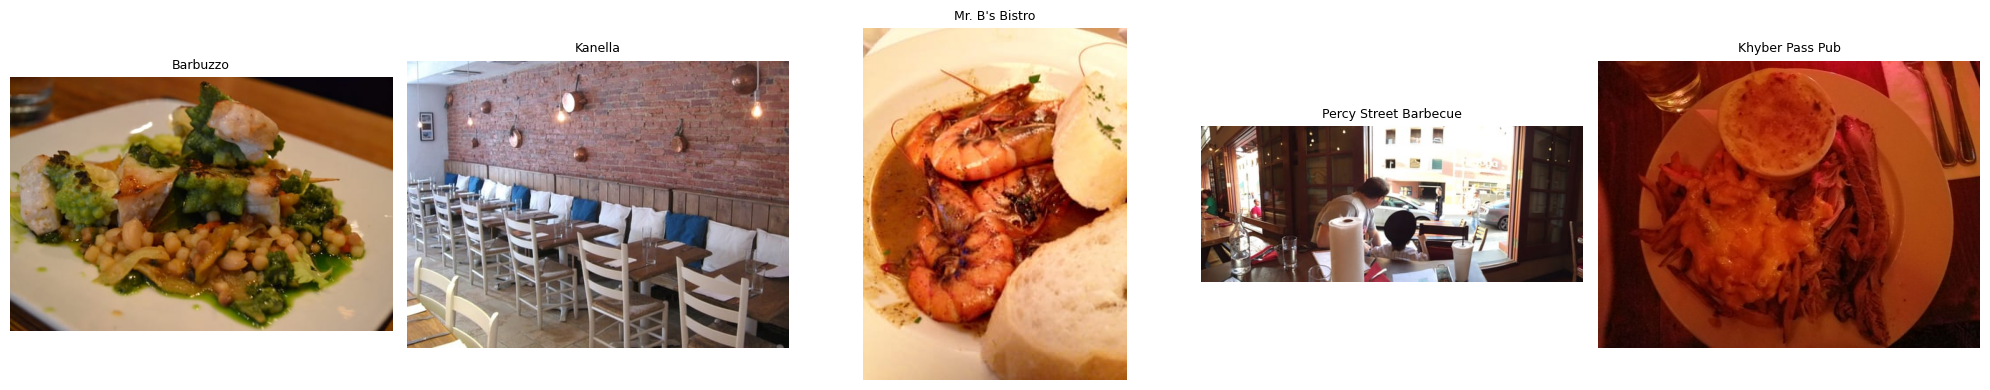


Usuario Qza0EVW1J_k0u8BIqMRbHQ  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Modo Mio - "I wish I could eat here every night. We tried Modo Mio on a Sunday night for their set priced family style dinner. We made reservations (the place isn't huge so..."
  [5*] Little Nonna's - "SOOOOOOOO good. I usually like pretty classic Italian dishes and Little Nona's has a smaller menu but everything is really a level up.   My one piece of advice ..."
  [4*] Townsend - "We came here for our anniversary dinner and had a lovely table upstairs near the window. They even wrote "Happy Anniversary" on the menu, which was a nice touch..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Barbuzzo (Philadelphia) - 4.5* - Mediterranean, Restaurants, Pizza, Italian
  2. Gran Caffe L'Aquila (Philadelphia) - 4.5* - Restaurants, Gelato, Coffee & Tea, Food, Italian, Bakeries

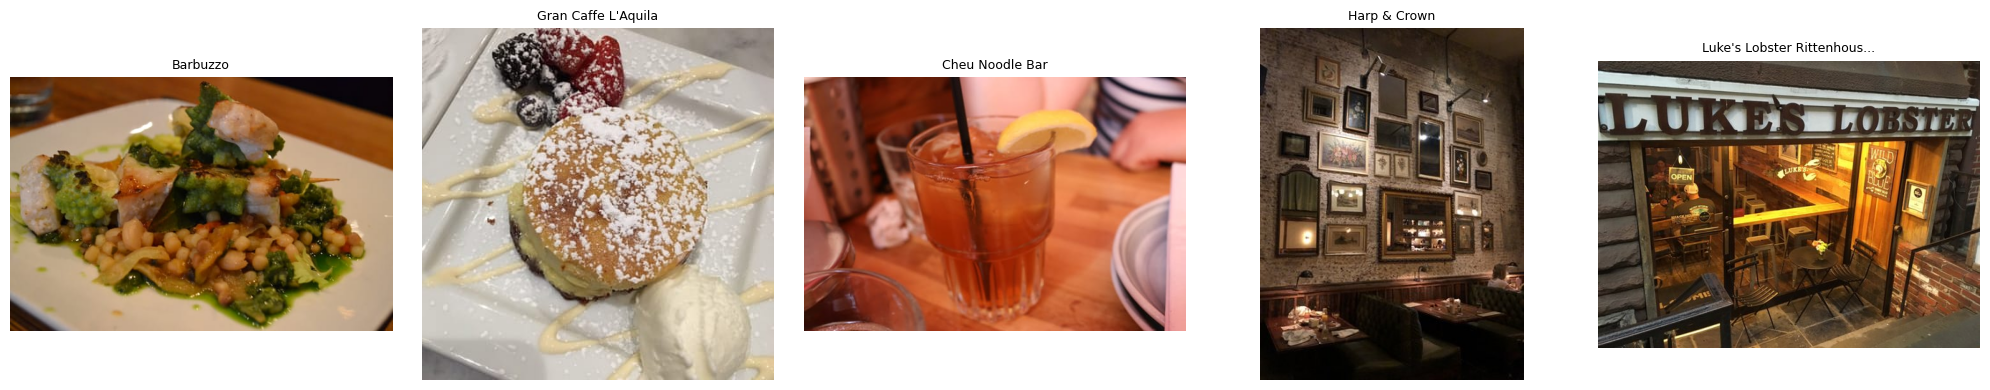


Usuario dt2VNqnnGdnYKor3uHkdlQ  |  8 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Petite Chou Bistro and Champagne Bar - "Love it!  So far our favorite brunch spot in Broad Ripple.  The atmosphere and outdoor seating are great and the ingredients and food are top notch.  I've had t..."
  [5*] Public Greens - "Yum!  Great location just off the Monon with a cute patio and long fire pit for cooler nights.  The menu is constantly changing based on local ingredients (many..."
  [5*] Milktooth - "Loved our first visit. Hour wait around noon on a Saturday in January. We ran a quick errand and then enjoyed some coffees outside while waiting (warm Jan. day ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Delicia (Indianapolis) - 4.5* - Latin American, Caribbean, Breakfast & Brunch, Restaurants, ...
  2. Shoefly Public House (Indianapolis) - 4.0* - Beer, Win

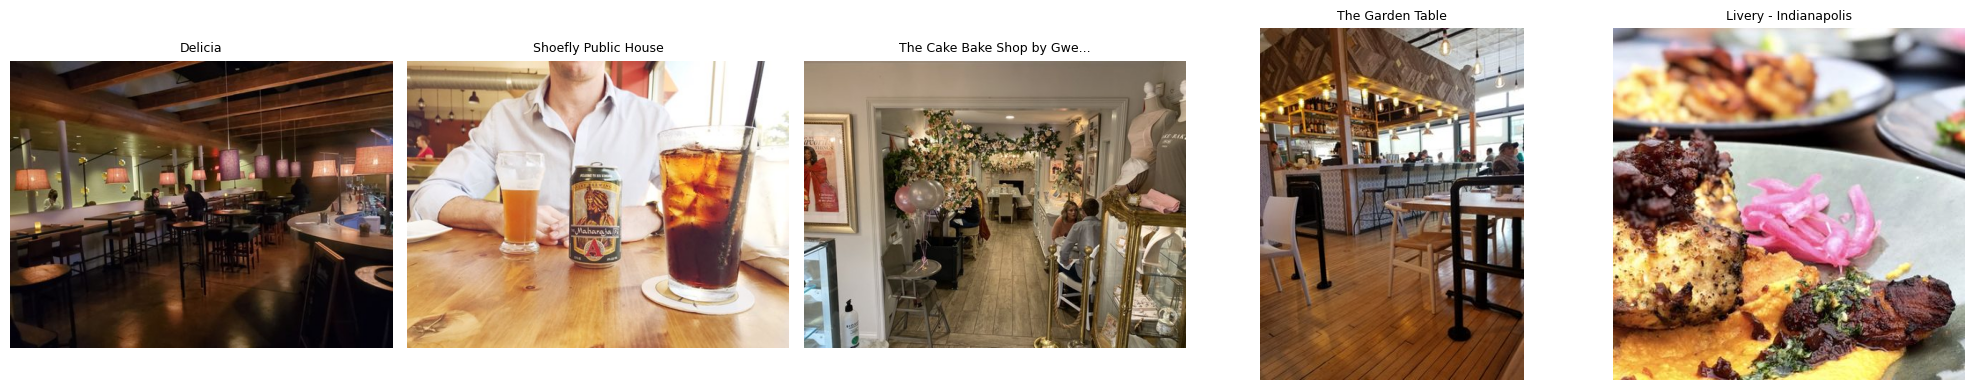


Usuario 4dwFGklOPRts-Tz2CSQZ9A  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Brocato's Sandwich Shop - "OMG this place is outrageous! If you plan on trying for the first time, plan on coming back in a week to fulfill your new addiction.   Very famous for Deviled C..."
  [5*] West Tampa Sandwich Shop - "Holy Cow! This was my very first time here and I can't believe I've waited this long!!   I had the Cuban with a ropa vieja empanada and both were unbelievably g..."
  [5*] Lee Roy Selmon's Restaurant - "The reliable Lee Roy Selmons, gotta love it! Decisions,decisions, decisions..... this is always the problem when eating here..  I really enjoy this place... I n..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Ella's Americana Folk Art Cafe (Tampa) - 4.0* - American (New), Cafes, Restaurants, Food
  2. Saigon Deli (Tampa) - 4.5* - Vietnamese, Deli

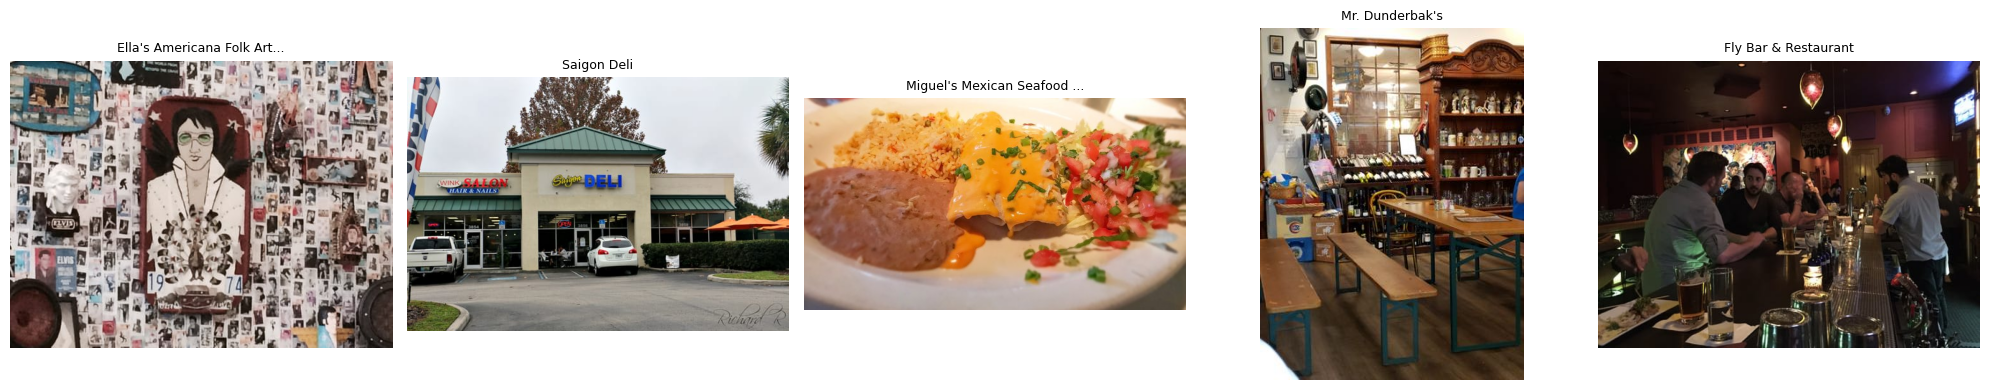


Usuario QdE2T1VEoc-QgNWKTMMixA  |  10 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Napolese Pizzeria - "Delicious pizza and a nice atmosphere. Their Paloma's were amazing and the service was great-- attentive without hovering."
  [5*] HopCat - Broad Ripple - "Two words: crack fries. They can't be beat. Hopcat boasts an impressive beer selection and they rotate regularly so there is always something new to try. It's a..."
  [5*] Quills Coffee - "Was downtown while my car was getting maintenance and needed a place to hang out. Found quills which is tucked back a bit on a side street and loved the cozy at..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Twenty Tap (Indianapolis) - 4.5* - American (New), Nightlife, Restaurants, Bars, Gastropubs, Lo...
  2. The Cake Bake Shop by Gwendolyn Rogers-Broad Ripple Village (Indianapolis) - 4.0* - Restaurants, B

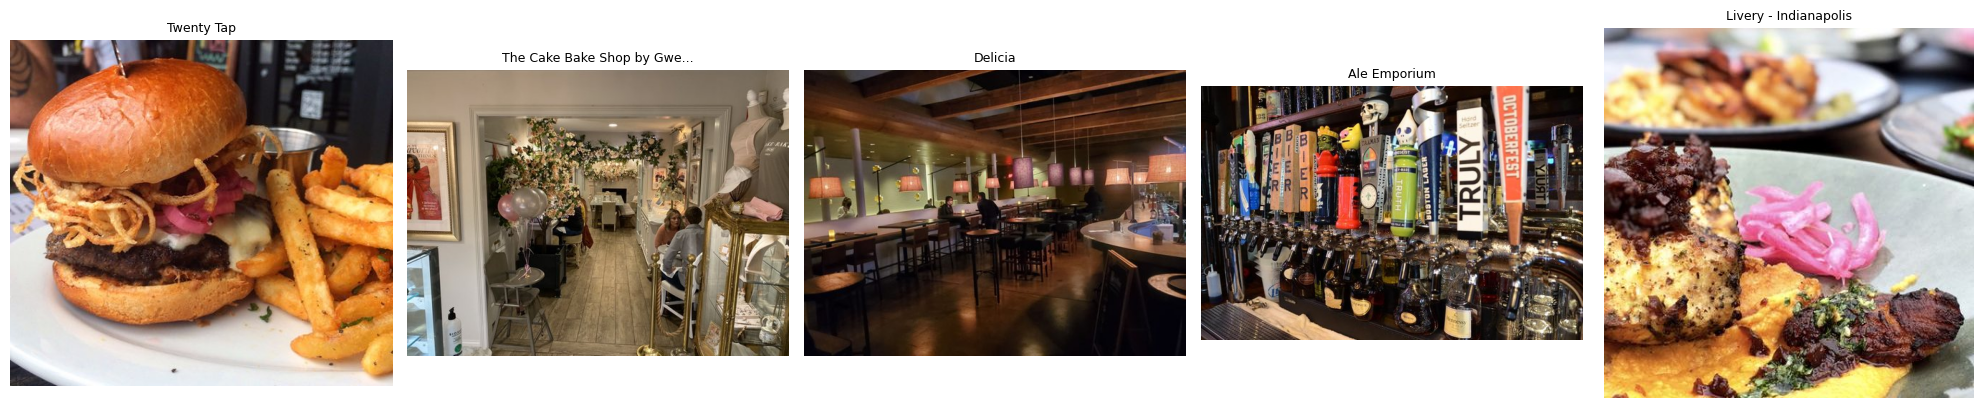

In [14]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )